# ITO5201 – Assessment 1: Section 1
## Model Complexity and Model Selection
**Student:** Johannes Coetzee  
**Student Number:** 36384852

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Iterable, Iterator
from numpy.typing import NDArray
from sklearn.base import BaseEstimator

DEBUG = False  # Set to True to enable debug output

---
## Question 1 – KNN Regressor
### Q1.I – Implement `KnnRegressor`


In [2]:
# MODEL: KNN Regressor

"""
Source: Adapted from Activity 1.1 (Modules/1/Activities/Activity.1.1_solutions.ipynb,
Tasks C-D: k-NN predict). Per the Section 1 background note, the classifier's
majority vote is replaced by the mean of the k neighbours' target values.

This class implements a K-Nearest Neighbors (KNN) regressor. 
It allows for fitting the model to training data and making predictions 
on new data points based on the average of the target values of the k nearest neighbors.
__init__ method initializes the number of neighbors (k) to consider.
fit method stores the training data (features and target values) for later use in predictions.
- x: Input features (numpy array)
- y: Target values (numpy array)
predict method computes the squared Euclidean distance between each test point and all training points,
- x: Input features for which predictions are to be made (numpy array)
It identifies the indices of the k nearest neighbors and calculates the mean of their target values to generate predictions.
- Returns: Predicted target values (numpy array)

Numpy functions used:
- np.array: Converts input data to a numpy array.
- np.sum: Computes the sum of array elements over a specified axis.
Ref: https://numpy.org/doc/stable/reference/generated/numpy.array.html
Ref: https://numpy.org/doc/stable/reference/generated/numpy.sum.html

"""

class KnnRegressor(BaseEstimator):
    def __init__(self, k: int = 5):
        self.k = k

    def fit(self, x: NDArray[np.float64], y: NDArray[np.float64]) -> 'KnnRegressor':
        self.x_train_ = x
        self.y_train_ = y
        return self

    def predict(self, x: NDArray[np.float64]) -> NDArray[np.float64]:
        x = np.array(x)
        predictions = []
        for test_point in x:
            # Squared Euclidean distance — sqrt omitted as argpartition only needs ranking
            sq_dist = np.sum((self.x_train_ - test_point) ** 2, axis=1)
            neighbour_idx = np.argpartition(sq_dist, self.k)[:self.k]
            predictions.append(np.mean(self.y_train_[neighbour_idx]))
        return np.array(predictions)
    # Note: scipy.spatial.KDTree would give O(log N) lookup but abstracts away
    # the distance computation; brute-force keeps the algorithm fully explicit.

### Q1.II – Evaluate on `diabetes` and `california_housing`


In [3]:
# DATA: Load datasets

from sklearn.datasets import load_diabetes, fetch_california_housing

# Load datasets
diabetes = load_diabetes()
california = fetch_california_housing()

"""
# Source: Adapted from Activity 1.1 (Activity.1.1.ipynb, Task B)
Function to split data into training and testing sets, 
with a specified training size and optional random state for reproducibility.
Parameters:
- x: Input features (numpy array)
- y: Target values (numpy array)
- train_size: Proportion of the dataset to include in the training set (default is 0.6)
- random_state: Seed for the random number generator (default is None)

Returns:
- A tuple containing the training and testing sets: (x_train, x_test, y_train, y_test)

Numpy functions used:
- np.random.default_rng: Creates a new random number generator.
- np.setdiff1d: Finds the set difference of two arrays.
Ref: https://numpy.org/doc/stable/reference/random/generator.html

"""

def train_test_split(
    x: NDArray[np.float64],
    y: NDArray[np.float64],
    train_size: float = 0.6,
    random_state: int | None = None,
) -> tuple[NDArray[np.float64], NDArray[np.float64], NDArray[np.float64], NDArray[np.float64]]:
    RNG = np.random.default_rng(random_state)
    N = len(x)
    N_train = round(N * train_size)
    idx_train = RNG.choice(N, N_train, replace=False)
    idx_test = np.setdiff1d(np.arange(N), idx_train)
    RNG.shuffle(idx_test)
    # Returns (x_train, x_test, y_train, y_test) — sklearn convention
    return x[idx_train], x[idx_test], y[idx_train], y[idx_test]

In [4]:
# HELPER: Compute error metrics
"""
    Source: Adapted from Activity 2.1 (Activity.2.1_solutions.ipynb)
    Here we use the standard 1/n MSE as in sklearn.metrics.mean_squared_error so that
    reported values are directly comparable to sklearn benchmarks and the target units.

"""

def _compute_sse(y_true: NDArray[np.float64], y_pred: NDArray[np.float64]) -> float:
    return np.sum((y_true - y_pred) ** 2)

def _compute_mse(y_true: NDArray[np.float64], y_pred: NDArray[np.float64]) -> float:
    return np.mean((y_true - y_pred) ** 2)

In [5]:
# EXECUTION: Train and evaluate KNN regressor on both datasets

"""
Cell runs the KNN regressor on two datasets: Diabetes and California Housing.
For each dataset, it splits the data into training and testing sets (60% training, 40% testing) using a fixed random seed for reproducibility.
It then fits the KNN regressor with k=5 on the training data and computes the Mean Squared Error (MSE) and Root Mean Squared Error (RMSE) for both the training and testing sets.
The results, including the MSE and RMSE values, are printed for each dataset.
"""

for name, dataset in [('Diabetes', diabetes), ('California Housing', california)]:
    X_train, X_test, Y_train, Y_test = train_test_split(
        dataset.data, dataset.target, train_size=0.6, random_state=42
    )
    knn_reg = KnnRegressor(k=5)
    knn_reg.fit(X_train, Y_train)

    train_mse  = _compute_mse(Y_train, knn_reg.predict(X_train))
    test_mse   = _compute_mse(Y_test,  knn_reg.predict(X_test))
    train_rmse = np.sqrt(train_mse)
    test_rmse  = np.sqrt(test_mse)
    print(f"{name} (K=5):")
    print(f"  Train MSE  : {train_mse:.4f}   Train RMSE : {train_rmse:.4f}")
    print(f"  Test  MSE  : {test_mse:.4f}   Test  RMSE : {test_rmse:.4f}")
    print()

Diabetes (K=5):
  Train MSE  : 2457.4379   Train RMSE : 49.5726
  Test  MSE  : 3285.5401   Test  RMSE : 57.3196



California Housing (K=5):
  Train MSE  : 0.7712   Train RMSE : 0.8782
  Test  MSE  : 1.1621   Test  RMSE : 1.0780



---
## Question 2 – L-Fold Cross Validation
### Q2.I – Implement `LFold`

In [6]:
# MODEL: Custom L-Fold Cross-Validation
nbr_of_folds = 5

class My_LFold:
    """
    Class to perform L-Fold cross-validation, similar to sklearn.model_selection.KFold.

    Source: the sklearn data-splitter interface (get_n_splits / split yielding
    train and test index arrays) follows Activity 1.2
    (Modules/1/Activities/Activity.1.2.ipynb, "Data splitters in scikit-learn").

    __init__ method initializes:
    - lfolds: Number of folds (must be an integer >= 2)
    - shuffled: Whether to shuffle the data before splitting into folds (default is False)
    - random_state: Seed for the random number generator (default is None)

    get_n_splits method returns the number of folds. The optional x/y/groups
    arguments are unused but accepted per the sklearn splitter convention, so
    utilities like sklearn.model_selection.cross_validate can call it.
    
    split method generates indices for training and testing sets for each fold.
    - x: Input features (numpy array or list; only its length is used)
    - y: Target values (optional, not used in this implementation)
    - groups: Group labels for the samples (optional, not used in this implementation)
    Yields:
    - train_idx: Indices for the training set
    - test_idx: Indices for the testing set

    NumPy functions used:
    - np.arange: Creates an array of evenly spaced values within a given range.
    - np.random.default_rng: Creates a random number generator instance.
    - np.random.shuffle: Shuffles the elements of an array in place.
    - np.full: Creates an array of given shape and fills it with a specified value.
    - np.concatenate: Joins a sequence of arrays along an existing axis.

    ref: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html
    ref: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html
    
    """
    def __init__(self, lfolds: int = nbr_of_folds, shuffled: bool = False, random_state: int | None = None):
        if not isinstance(lfolds, int) or lfolds < 2:
            raise ValueError(f"lfolds must be an integer >= 2, got {lfolds}")
        if not isinstance(shuffled, bool):
            raise TypeError(f"shuffled must be a bool, got {type(shuffled).__name__}")
        self.lfolds = lfolds
        self.shuffled = shuffled
        self.random_state = random_state

    def get_n_splits(self, x=None, y=None, groups=None) -> int:
        return self.lfolds

    def split(
        self,
        x: NDArray[np.float64] | list,
        y: NDArray[np.float64] | None = None,
        groups: NDArray[np.float64] | None = None,
    ) -> Iterator[tuple[NDArray[np.intp], NDArray[np.intp]]]:
        N = len(x)
        if self.lfolds > N:
            raise ValueError(f"Cannot have lfolds={self.lfolds} folds with only {N} samples")
        indices = np.arange(N)
        if self.shuffled:
            rng = np.random.default_rng(self.random_state)
            rng.shuffle(indices)
        fold_sizes = np.full(self.lfolds, N // self.lfolds, dtype=int)
        fold_sizes[:N % self.lfolds] += 1
        current = 0
        for fold_size in fold_sizes:
            start, stop = current, current + fold_size
            test_idx = indices[start:stop]
            train_idx = np.concatenate([indices[:start], indices[stop:]])
            current = stop
            yield train_idx, test_idx 


In [7]:
# Verify LFold correctness
"""
This code snippet verifies the correctness of the My_LFold class by creating an instance of it with a 
specified number of folds (nbr_of_folds) and then using the split method to generate training and 
testing indices for a dataset of size 20. It prints out the training and testing indices for each fold, 
allowing you to visually inspect that the splits are correct and that each sample is used exactly once in the test set across all folds.
"""

for idx_train, idx_test in My_LFold(lfolds=nbr_of_folds).split(list(range(20))):
    print(idx_train, idx_test)

[ 4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19] [0 1 2 3]
[ 0  1  2  3  8  9 10 11 12 13 14 15 16 17 18 19] [4 5 6 7]
[ 0  1  2  3  4  5  6  7 12 13 14 15 16 17 18 19] [ 8  9 10 11]
[ 0  1  2  3  4  5  6  7  8  9 10 11 16 17 18 19] [12 13 14 15]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] [16 17 18 19]


### Q2.II – CV Experiment: K=1..50

In [8]:
# Square Distance Function

def square_distance(
    query_points: NDArray[np.float64],
    X_ref: NDArray[np.float64],
    ref_sq: NDArray[np.float64],
) -> NDArray[np.float64]:
    """
    Computes the squared Euclidean distance between each query point and all reference points.
    Parameters:
    - query_points: A 2D numpy array of shape (n_query, n_features) representing the query points.
    - X_ref: A 2D numpy array of shape (n_ref, n_features) representing the reference points.
    - ref_sq: A 1D numpy array of shape (n_ref,) with the precomputed squared norms ||r||^2 of the reference points.
    Returns:
    - A 2D numpy array of shape (n_query, n_ref) containing the squared distances.

    Formula used: ||q - r||^2 = ||q||^2 - 2 * (q . r) + ||r||^2
    Note: floating-point cancellation can yield tiny negative values (e.g. a point's
    distance to itself ~ -1e-12); this is harmless as only the ranking is used.
    ref: https://en.wikipedia.org/wiki/Euclidean_distance#Squared_Euclidean_distance
    """

    # 1. First, compute the squared distances
    distance = query_points ** 2

    # 2. Then, compute the dot product between query points and reference points
    # Multiplying by 2.0 to account for the -2 * (q . r) term in the squared distance formula
    # Transpose X_ref to align dimensions for matrix multiplication
    # Note: Using @ operator for matrix multiplication, which is equivalent to np.matmul
    # ref: https://numpy.org/doc/stable/reference/generated/numpy.matmul.html
    dot_product = 2.0 * query_points @ X_ref.T 

    # 3. Slice the squared distances of the reference points (||r||^2) for broadcasting
    distance = distance.sum(axis=1)[:, None]  # Shape (n_query, 1)

    # 4. Slice the ref_sq for broadcasting to match the shape of the distance matrix
    ref_sq = ref_sq[None, :]  # Shape (1, n_ref)

    # 5. Finally, return the squared distances using broadcasting to compute ||q - r||^2 for all query and reference points 
    return distance - dot_product + ref_sq  # Shape (n_query, n_ref)


In [9]:
# HELPER: Compute nearest neighbor indices
def _compute_neighbor_indices(
    X_query: NDArray[np.float64],
    X_ref: NDArray[np.float64],
    max_k: int,
    batch_size: int = 2048,
) -> NDArray[np.intp]:
    """
    For each point in X_query return the indices of its max_k nearest neighbours
    in X_ref, sorted by distance. Batched to keep memory manageable.

    Squared distances are computed via the expansion
        ||q - r||^2 = ||q||^2 - 2 q.r + ||r||^2
    (see square_distance) so the dominant cost is a single matrix multiply
    (Q @ X_ref.T) per batch rather than a large (batch, n_ref, n_features)
    difference tensor, which keeps the per-batch memory footprint small and
    the computation vectorised.
    sqrt is omitted throughout as squared distance preserves the neighbour ranking.

    Parameters:
    - X_query: (n_query, n_features) array of query points
    - X_ref:   (n_ref, n_features) array of reference points
    - max_k:   maximum number of neighbours to return
    - batch_size: number of query points to process at once
    Returns:
    - nearest_n_idx: (n_query, max_k) array of indices of nearest neighbours in X_ref
    Raises:
    - ValueError: if inputs are not 2-D, feature dimensions differ,
      or max_k is not in [1, len(X_ref) - 1].
    NumPy functions used:
    - np.empty: Creates an uninitialized array of given shape and dtype.
    - np.argpartition: Performs an indirect partition along the given axis.
    - np.argsort: Returns the indices that would sort an array.
    - np.arange: Creates an array of evenly spaced values within a given range.
    Ref: https://numpy.org/doc/stable/reference/generated/numpy.argpartition.html

    """
    # 0. Validate inputs so failure modes are explicit rather than cryptic numpy errors
    if X_query.ndim != 2 or X_ref.ndim != 2:
        raise ValueError("X_query and X_ref must be 2-D (n_points, n_features) arrays")
    if X_query.shape[1] != X_ref.shape[1]:
        raise ValueError(f"feature dimensions differ: {X_query.shape[1]} != {X_ref.shape[1]}")
    if not 0 < max_k < len(X_ref):
        raise ValueError(f"max_k must be in [1, {len(X_ref) - 1}], got {max_k}")

    n_query = len(X_query) # Number of query points
    ref_sq = (X_ref ** 2).sum(axis=1)  # ||r||^2 — computed once, reused for every batch, significantly reduces computation time
    nearest_n_idx = np.empty((n_query, max_k), dtype=np.intp) # empty array to store the indices of the nearest neighbors for each query point - shape (n_query, max_k)
    
    for start in range(0, n_query, batch_size): 
        # 1. Compute the end index for the current batch, ensuring it does not exceed n_query
        end: int = min(start + batch_size, n_query) # End index for the current batch

        # 2. Compute the number of query points in the current batch
        nbr_query_points: int = end - start # Number of query points in the current batch

        # 3. Extract the query points for the current batch
        query_points: NDArray[np.float64] = X_query[start:end] # Query points for the current batch

        # 4. Compute the squared distances between the current batch of query points and all reference points
        sq_dist = square_distance(query_points, X_ref, ref_sq) # Shape (nbr_query_points, n_ref)

        # 5. Use np.argpartition to find the indices of the max_k nearest neighbors for each query point in the current batch
        # This returns an unordered array of shape (nbr_query_points, max_k)
        part  = np.argpartition(sq_dist, max_k, axis=1)[:, :max_k]

        # 6. Extract the squared distances of the nearest neighbors for sorting
        top_sq = sq_dist[np.arange(nbr_query_points)[:, None], part] 

        # 7. Use np.argsort to sort the nearest neighbors by their squared distances
        order = np.argsort(top_sq, axis=1)

        # 8. Store the sorted indices of the nearest neighbors in the nearest_n_idx array for the current batch
        nearest_n_idx[start:end] = part[np.arange(nbr_query_points)[:, None], order]

     # 9. Return the complete array of nearest neighbor indices for all query points   
    return nearest_n_idx


In [10]:
# EXECUTION: Run L-Fold CV for each K and return mean/std of train and test MSE

def run_cv_experiment( X: NDArray[np.float64], y: NDArray[np.float64], k_range: Iterable[int] = range(1, 51), lfolds: int = nbr_of_folds) -> dict[str, list[float]]:
    
    """
    Run L-fold CV for each K and return mean/std of train and test MSE.
    Returns: dict with keys 'train_mean', 'train_std', 'test_mean', 'test_std'

    Phase 1 — neighbour indices are pre-computed once per fold (not once per K).
    Phase 2 — K loop reuses cached indices via cheap numpy slicing.
    Distance computations reduced from O(n_k * n_folds) to O(n_folds).

    Parameters:
    - X: (n_samples, n_features) array of input features
    - y: (n_samples,) array of target values
    - k_range: iterable of K values to evaluate
    - lfolds: number of folds for cross-validation

    REturns:
    - results: dict with keys:
      'train_mean',                 # mean of train MSE for each K
      'train_std',                  # std of train MSE for each K
      'test_mean',                  # mean of test MSE for each K
      'test_std',                   # std of test MSE for each K
    each containing a list of values corresponding to k_range

    NumPy functions used:
    - np.mean: Computes the arithmetic mean along the specified axis.
    - np.std: Computes the standard deviation along the specified axis.
    
    Ref: https://numpy.org/doc/stable/reference/generated/numpy.mean.html
    Ref: https://numpy.org/doc/stable/reference/generated/numpy.std.html
    """

    results = {
        'train_mean': [], 'train_std': [],
        'test_mean':  [], 'test_std':  [],
    }
    k_list = list(k_range)
    max_k  = max(k_list)
    total  = len(k_list)

    splits = list(My_LFold(lfolds=lfolds, shuffled=True, random_state=42).split(X))

    # Phase 1: compute neighbour indices once per fold
    fold_data = []
    for f, (train_idx, test_idx) in enumerate(splits):
        X_train, X_test = X[train_idx], X[test_idx]
        print(f"  Pre-computing fold {f+1}/{lfolds} neighbour indices...", flush=True) if DEBUG else None
        test_nn  = _compute_neighbor_indices(X_test,  X_train, max_k)
        train_nn = _compute_neighbor_indices(X_train, X_train, max_k)
        fold_data.append((y[train_idx], y[test_idx], test_nn, train_nn))

    # Phase 2: sweep K — no distance recomputation, indices already cached
    for i, k in enumerate(k_list):
        train_mse_list = []
        test_mse_list  = []
        for y_train, y_test, test_nn, train_nn in fold_data:
            test_preds  = y_train[test_nn[:,  :k]].mean(axis=1)
            train_preds = y_train[train_nn[:, :k]].mean(axis=1)
            train_mse_list.append(_compute_mse(y_train, train_preds))
            test_mse_list.append(_compute_mse(y_test,  test_preds))
        results['train_mean'].append(np.mean(train_mse_list))
        results['train_std'].append(np.std(train_mse_list))
        results['test_mean'].append(np.mean(test_mse_list))
        results['test_std'].append(np.std(test_mse_list))
        print(f"  K={k:>3}  [{i+1}/{total}]  {(i+1)/total*100:.0f}% complete", flush=True) if DEBUG else None

    return results


In [11]:
# EXECUTION: Run on both datasets

"""
This cell runs the cross-validation experiments on both the diabetes and California housing datasets using the run_cv_experiment function. 
It stores the results in two separate dictionaries, results_diabetes and results_california, 
which contain the mean and standard deviation of the training and testing MSE for each value of K in the specified range.
"""

results_diabetes   = run_cv_experiment(diabetes.data, diabetes.target)
results_california = run_cv_experiment(california.data, california.target)

In [12]:
# REPORT: Report best K per dataset (Q2.II requirement)

"""
This cell identifies and reports the best value of K for each dataset based on the mean test MSE obtained from the cross-validation experiments.
It iterates over the results for both datasets, finds the K that yields the lowest mean test MSE, 
and prints the best K along with the corresponding mean test MSE for each dataset.
"""

for name, results in [('Diabetes', results_diabetes), ('California Housing', results_california)]:
    best_k  = np.argmin(results['test_mean']) + 1
    best_mse = results['test_mean'][best_k - 1]
    print(f"{name}: best K = {best_k}  (mean test MSE = {best_mse:.4f})")

Diabetes: best K = 16  (mean test MSE = 3249.8788)
California Housing: best K = 7  (mean test MSE = 1.1149)


### Q2.III – Plots with STE Error Bars

In [13]:
# HELPER: Report best and worst K values
def _salient_points(results: dict[str, list[float]], dataset_name: str) -> None:
    """
    Function to print the best and worst K values based on test MSE,
    along with their corresponding train and test MSE values.

    Parameters:
    - results: dict containing 'train_mean', 'train_std', 'test_mean', 'test_std' for each K
    - dataset_name: name of the dataset (string) for display purposes    

    Numpy functions used:
    - np.argmin: Returns the indices of the minimum values along an axis.
    - np.argmax: Returns the indices of the maximum values along an axis.

    Ref: https://numpy.org/doc/stable/reference/generated/numpy.argmin.html
    Ref: https://numpy.org/doc/stable/reference/generated/numpy.argmax.html
    """

    best_k = np.argmin(results['test_mean']) + 1
    worst_k = np.argmax(results['test_mean']) + 1
    print(f"Results for {dataset_name}:")
    print("" + "-"*50)
    print(f"Best K: {best_k}")
    print(f"Worst K: {worst_k}")
    print(f"Train MSE for Best K ({best_k}): {results['train_mean'][best_k-1]:.4f}")
    print(f"Train MSE for Worst K ({worst_k}): {results['train_mean'][worst_k-1]:.4f}")
    print(f"Test MSE for Best K ({best_k}): {results['test_mean'][best_k-1]:.4f}")
    print(f"Test MSE for Worst K ({worst_k}): {results['test_mean'][worst_k-1]:.4f}")
    print("" + "-"*50)
    print("\n")
    
    

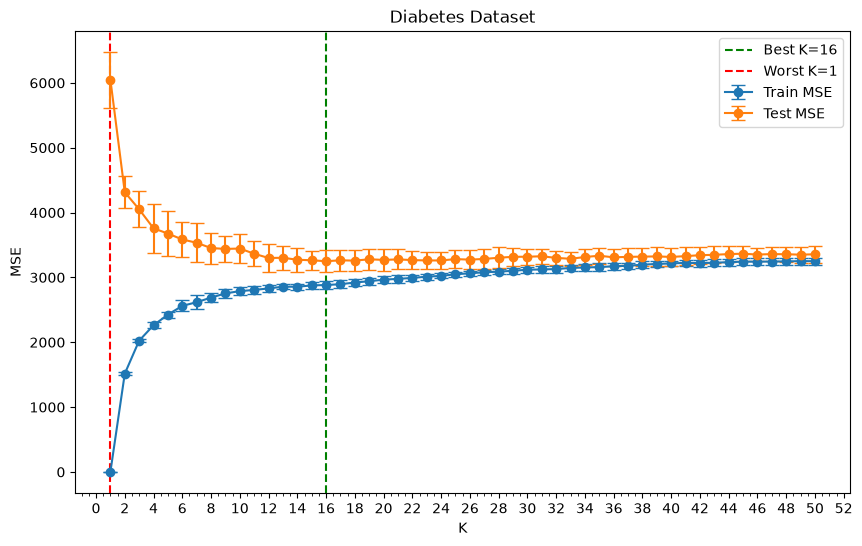

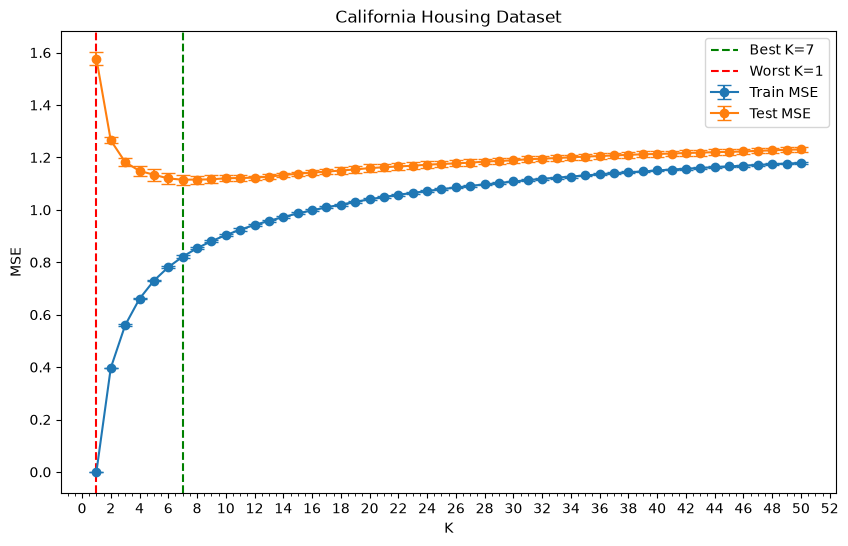

Results for Diabetes:
--------------------------------------------------
Best K: 16
Worst K: 1
Train MSE for Best K (16): 2882.9373
Train MSE for Worst K (1): 0.0000
Test MSE for Best K (16): 3249.8788
Test MSE for Worst K (1): 6048.8448
--------------------------------------------------


Results for California Housing:
--------------------------------------------------
Best K: 7
Worst K: 1
Train MSE for Best K (7): 0.8213
Train MSE for Worst K (1): 0.0000
Test MSE for Best K (7): 1.1149
Test MSE for Worst K (1): 1.5767
--------------------------------------------------




In [14]:
# REPORT AND DISPLAY: Plot mean train/test MSE vs K with STE error bars

from matplotlib.ticker import AutoMinorLocator, MultipleLocator

def plot_cv_results(results: dict[str, list[float]], title: str, lfolds: int = nbr_of_folds) -> None:
    """
    Plot mean train/test MSE vs K with STE error bars.
    STE = 1.96 * std / sqrt(L)

    Parameters:
    - results: dict containing 'train_mean', 'train_std', 'test_mean', 'test_std' for each K
    - title: title of the plot (string)
    - lfolds: number of folds for cross-validation (default: nbr_of_folds)

    Numpy functions used:
    - np.argmin: Returns the indices of the minimum values along an axis.
    - np.argmax: Returns the indices of the maximum values along an axis.
    - np.sqrt: Computes the non-negative square root of an array, element-wise.
    Ref: https://numpy.org/doc/stable/reference/generated/numpy.argmin.html
    Ref: https://numpy.org/doc/stable/reference/generated/numpy.argmax.html
    """

    train_ste = []
    test_ste = []

    k_values = range(1, len(results['train_mean']) + 1) # K values from 1 to max K
    best_k = np.argmin(results['test_mean']) + 1 # Best K based on minimum test MSE
    worst_k = np.argmax(results['test_mean']) + 1 # Worst K based on maximum test MSE

    for k, train_mse, test_mse in zip(k_values, results['train_mean'], results['test_mean']):
        print(f"K={k:>3}  Train MSE={train_mse:.4f}  Test MSE={test_mse:.4f}") if DEBUG else None
        train_ste.append(1.96 * results['train_std'][k-1] / np.sqrt(lfolds))
        test_ste.append(1.96 * results['test_std'][k-1] / np.sqrt(lfolds))


    fig, ax = plt.subplots(figsize=(10, 6))
    ax.xaxis.set_major_locator(MultipleLocator(2))  # Ensure x-axis has integer ticks
    ax.xaxis.set_minor_locator(AutoMinorLocator(4))  # Optional: add minor ticks for better granularity
    ax.axvline(x=best_k, color='green', linestyle='--', label=f'Best K={best_k}')
    ax.axvline(x=worst_k, color='red', linestyle='--', label=f'Worst K={worst_k}')

    ax.errorbar(k_values, results['train_mean'], yerr=train_ste, label='Train MSE', fmt='-o', capsize=5)
    ax.errorbar(k_values, results['test_mean'], yerr=test_ste, label='Test MSE', fmt='-o', capsize=5)
    ax.set_title(title)
    ax.set_xlabel('K')
    ax.set_ylabel('MSE')
    ax.legend()
    plt.show()

# EXECUTION: Plot results for both datasets
plot_cv_results(results_diabetes, 'Diabetes Dataset')
plot_cv_results(results_california, 'California Housing Dataset')

# REPORT: Print salient points for both datasets
_salient_points(results_diabetes, "Diabetes")
_salient_points(results_california, "California Housing")


### Discussion: Effect of K (Overfitting / Underfitting)

---

## Diabetes Dataset

### Overfitting region (K = 1-8)

* K = 1 gives Train MSE $\approx$ 0 - i.e. the model memorises every training point perfectly. Test MSE $\approx$ 6,049. This point represents the highest overfitting point.
* The STE error bars at K=1 are enormous (±~500), meaning the fold-to-fold test MSE varies wildly — a direct consequence of high model variance.
* Test MSE drops steeply from ~6,050 at K=1 to ~3,400 by K=8. Each additional neighbour significantly dilutes noise.

### Optimal region (K ≈ 12–16)

* Test MSE reaches its minimum around 3,200–3,250 (Visual Estimation) in the K=12–16 range. 
* Error bars have narrowed substantially by this point, indicating a stable CV estimate.
* The train-test gap is still visible (~500 MSE) but no longer driven by memorisation.

### Underfitting region K >= 20

* Test MSE begins to rise (3,400 to 3,500) from K=20 onward.
* Train MSE continues rising and nearly meets test MSE by K50
* The curves converging signals the model is averaging too broadly - it approaches predicting the global mean, introducing bias
* Error bars are very small at this point - predictions are stable but systemically wrong.

---

## California Housing Dataset

### Overfitting region (K = 1-5)

* K = 1: Train MSE = 0, Test MSE $\approx$ = 1.57
* K = 7: Train MSE = 0.8213, Test MSE $\approx$ = 1.11
* Test MSE drops sharply to ~1.11 by K=5–7. The descent is steeper and faster than Diabetes, reflecting stronger local spatial structure in housing data — nearby houses are genuinely similar. 
* Error bars are extremely tight throughout (barely visible), because each fold has ~4,000+ test samples producing very reliable fold MSE estimates.

### Optimal region (K = 5-10)

* Test MSE minimum ≈ 1.10 at approximately K=5–7.
* The minimum is shallow and flat between K=5 and K=12 — the model is relatively insensitive to exact K choice in this range.
* Best K is significantly lower than Diabetes, confirming stronger local structure.

### Underfitting region (K >= 12)

* Test MSE rises gradually from 1.10 to ~1.25 at K=50.
* Train MSE rises to ~1.18. The two curves are converging but the gap (~0.07) remains, unlike Diabetes where they nearly meet.

---

**Note on feature standardisation**: California Housing features are not pre-standardised (unlike the diabetes dataset — see Activity 2.2). KNN Euclidean distances are therefore dominated by the largest-scale features (latitude and longitude, both O(10–100)), meaning the optimal K and MSE values above would likely shift if a `StandardScaler` were applied first.

---

*Source: Effect of L on CV stability is demonstrated in Activity 2.3 (`Activity.2.3_solutions.ipynb`) via the `reps` loop: more repetitions of the bias-variance experiment reduce estimation variance. The L-fold analogue is that more folds reduce the variance of the CV error estimate, at increased computational cost.*

### Discussion: Effect of L on CV Stability

The error bars are direct evidence of CV variance, and their behaviour differs substantially between the two datasets because of the difference in $N$.

For the Diabetes dataset ($N \approx 442$), each test fold at $L=5$ contains only ~88 samples, so individual fold MSE estimates are noisy. At $K=1$ the STE is $\approx \pm500$ — enormous relative to the signal. The multi-panel plot below illustrates the effect directly: at $L=2$ the test curve is erratic and the selected $K$ is unreliable, while at $L=20$ the error bars shrink noticeably and the apparent optimal $K$ stabilises. L therefore has a meaningful practical impact on this dataset.

For California Housing ($N \approx 20{,}640$), each fold already has ~4,000+ samples, so individual fold MSE estimates are very stable regardless of $L$. Error bars are barely visible at $L=5$ and would change little at $L=2$ or $L=20$. For large datasets, the choice of $L$ matters far less — the dominant source of uncertainty is the data, not the number of folds.

In general, increasing $L$ reduces the variance of the CV estimate (more folds to average over) and the bias (more training data per fold), but at greater computational cost. The benefit is most pronounced when $N$ is small.

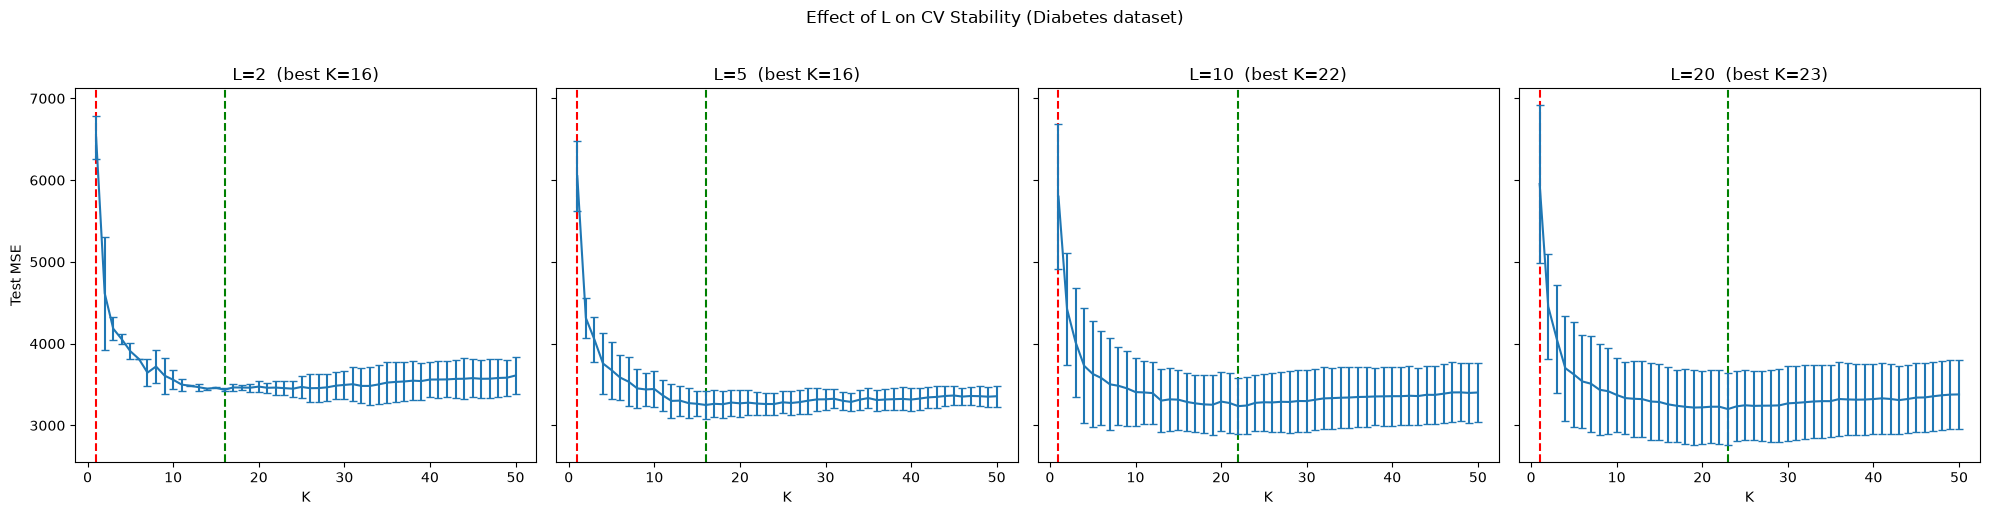

In [15]:
# Repeat CV experiment on Diabetes with different values of L to illustrate stability effect
"""
This cell runs the cross-validation experiments on the diabetes dataset with different values of 
L (number of folds) to illustrate the effect of L on the stability of the cross-validation results.

The experiment is conducted for L values of 2, 5, 10, and 20. 
For each value of L, the mean test MSE and its standard error are computed for each K. 
The results are then plotted in a 1x4 grid of subplots, where each subplot corresponds to a different value of L.
 The best K for each L is also indicated in the subplot titles.

"""


fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for axis, l_folds in zip(axes, [2, 5, 10, 20]):
    results_l = run_cv_experiment(diabetes.data, diabetes.target, lfolds=l_folds)
    k_values  = range(1, len(results_l['test_mean']) + 1)
    ste       = 1.96 * np.array(results_l['test_std']) / np.sqrt(l_folds)
    best_k    = k_values[np.argmin(results_l['test_mean'])]
    worst_k   = k_values[np.argmax(results_l['test_mean'])]
    # Add a line to indicate the best K for each L
    axis.axvline(x=best_k, color='green', linestyle='--', label=f'Best K={best_k}')
    # Add a line to indicate the worst K for each L
    axis.axvline(x=worst_k, color='red', linestyle='--', label=f'Worst K={worst_k}')
    axis.errorbar(k_values, results_l['test_mean'], yerr=ste, fmt='-', capsize=3)
    axis.set_title(f"L={l_folds}  (best K={best_k})")
    axis.set_xlabel("K")
    axis.set_ylabel("Test MSE" if l_folds == 2 else "")

plt.suptitle("Effect of L on CV Stability (Diabetes dataset)", y=1.02)
plt.tight_layout()
plt.show()


---
## Question 3 – Automatic Model Selection
### Q3.I – Implement `KnnRegressorCV`

In [16]:
# MODEL: KNN Regressor with internal CV for K selection

class KnnRegressorCV(BaseEstimator):
    """
    Class to perform KNN regression with internal cross-validation for selecting the best K.
    __init__ method initializes:
    - ks: List of K values to evaluate (default is range(1, 21))
    - cv: Cross-validation strategy (default is My_LFold with 5 folds)

    fit method trains the model on the provided data and selects the best K based on cross-validation.
    It uses the same two-phase pattern as run_cv_experiment to avoid recomputing distances for every candidate k:
    Phase 1 — neighbour indices are pre-computed once per inner fold with max(ks)
              neighbours (not once per k), via _compute_neighbor_indices.
    Phase 2 — the k sweep reuses the cached indices with cheap numpy slicing, so
              distances are computed len(ks) times less often than a naive loop
              that refits KnnRegressor for every k.
    On ties, strict '<' keeps the first k in ks order.
    - x: Input features (numpy array)
    - y: Target values (numpy array)
    REturns:
    - self: Returns the instance itself after fitting

    predict method makes predictions on new data using the best K selected during fitting.
    - x: Input features (numpy array)
    Returns:
    - predictions: Predicted target values (numpy array)

    Numpy functions used:
    - np.mean: Computes the arithmetic mean along the specified axis.
    Ref: https://numpy.org/doc/stable/reference/generated/numpy.mean.html

    """

    def __init__(self, ks: list[int] = list(range(1, 21)), cv: My_LFold = My_LFold(5)):
        self.ks = ks
        self.cv = cv
        self.k_: int | None = None  # best K selected by internal CV

    def fit(self, x: NDArray[np.float64], y: NDArray[np.float64]) -> 'KnnRegressorCV':
        self.x_train_ = x
        self.y_train_ = y
        max_k = max(self.ks)

        # Phase 1: compute neighbour indices once per inner fold
        fold_data = []
        for train_idx, test_idx in self.cv.split(x):
            nn = _compute_neighbor_indices(x[test_idx], x[train_idx], max_k)
            fold_data.append((y[train_idx], y[test_idx], nn))

        # Phase 2: sweep k — no distance recomputation, indices already cached
        best_mse = float('inf')
        for k in self.ks:
            mse_list = []
            for y_train, y_test, nn in fold_data:
                y_pred = y_train[nn[:, :k]].mean(axis=1)
                mse_list.append(_compute_mse(y_test, y_pred))
            avg_mse = np.mean(mse_list)
            if avg_mse < best_mse:
                best_mse = avg_mse
                self.k_ = k
        return self


    def predict(self, x: NDArray[np.float64]) -> NDArray[np.float64]:
        knn = KnnRegressor(k=self.k_)
        knn.fit(self.x_train_, self.y_train_)
        return knn.predict(x)
    

### Q3.II – Evaluate with Outer CV (Nested CV)

In [17]:
# HELPER: Evaluate KnnRegressorCV using nested (outer) 5-fold CV

def evaluate_knn_regressor_cv(
    X: NDArray[np.float64],
    y: NDArray[np.float64],
    dataset_name: str,
    best_k_q2: int,
    ks: list[int] = list(range(1, 21)),
    cv: My_LFold | None = None,
) -> tuple[list[int], list[float]]:
    """
    Evaluate KnnRegressorCV using nested (outer) 5-fold CV.
    Reports the K selected by internal CV per outer fold, the test MSE per fold,
    and compares the mean and modal selected K against the best K found in Q2
    (the mode is only meaningful when selections repeat across folds).

    Parameters:
    - X: (n_samples, n_features) array of input features
    - y: (n_samples,) array of target values
    - dataset_name: name of the dataset (string) for display purposes
    - best_k_q2: best K found in Q2 (int)
    - ks: list of K values to evaluate (default is range(1, 21))
    - cv: cross-validation strategy for internal CV (default is My_LFold with 5 folds)

    Returns:
    - selected_ks: list of K values selected by internal CV for each outer fold
    - test_mses: list of test MSE values for each outer fold

    """
    outer_cv = My_LFold(lfolds=5, shuffled=True, random_state=42)
    inner_cv = cv if cv is not None else My_LFold(lfolds=5)
    selected_ks, test_mses = [], []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        knn_cv = KnnRegressorCV(ks=ks, cv=inner_cv)
        knn_cv.fit(X_train, y_train)
        mse = _compute_mse(y_test, knn_cv.predict(X_test))

        selected_ks.append(knn_cv.k_)
        test_mses.append(mse)
        print(f"  Fold {fold+1}: K={knn_cv.k_}  Test MSE={mse:.4f}")

    mean_k  = np.mean(selected_ks)
    modal_k = max(set(selected_ks), key=selected_ks.count)
    print(f"\n{dataset_name} summary")
    print(f"  K selected per fold : {selected_ks}")
    print(f"  Test MSE per fold   : {[round(m, 4) for m in test_mses]}")
    print(f"  Mean test MSE       : {np.mean(test_mses):.4f}")
    print(f"  Best K from Q2      : {best_k_q2}")
    print(f"  Mean K selected     : {mean_k:.1f}")
    print(f"  Modal K selected    : {modal_k}  "
          f"({'agrees' if modal_k == best_k_q2 else 'differs'} with Q2)")
    return selected_ks, test_mses


In [18]:
# EXECUTION: Evaluate KnnRegressorCV on both datasets using nested CV

"""
THis cell evaluates the KnnRegressorCV model on both the diabetes and California housing datasets using nested cross-validation.
It computes the best K from the previous Q2 results and uses it to compare against the K values selected by the internal cross-validation of the KnnRegressorCV model. 
The results, including the selected K values and test MSE for each outer fold, are printed for both datasets.

NumPy functions used:
- np.argmin: Returns the indices of the minimum values along an axis.
Ref: https://numpy.org/doc/stable/reference/generated/numpy.argmin.html
"""

# Compute best K from Q2 L=5 results inline — safe against kernel restart / cell order
_k_vals = list(range(1, len(results_diabetes['test_mean']) + 1))

# Obtain the best K for diabetes and California housing datasets based on the minimum test MSE from the previous results
_best_k_diabetes   = _k_vals[np.argmin(results_diabetes['test_mean'])]
_best_k_california = _k_vals[np.argmin(results_california['test_mean'])]

print("=== Diabetes ===")
diabetes_selected_ks, diabetes_outer_mses = evaluate_knn_regressor_cv(
    diabetes.data, diabetes.target, "Diabetes", best_k_q2=_best_k_diabetes
)

print("\n=== California Housing ===")
california_selected_ks, california_outer_mses = evaluate_knn_regressor_cv(
    california.data, california.target, "California Housing", best_k_q2=_best_k_california
)


=== Diabetes ===
  Fold 1: K=16  Test MSE=3456.3006
  Fold 2: K=15  Test MSE=3173.4886
  Fold 3: K=11  Test MSE=3331.4404
  Fold 4: K=14  Test MSE=2963.3402
  Fold 5: K=17  Test MSE=3376.6517

Diabetes summary
  K selected per fold : [16, 15, 11, 14, 17]
  Test MSE per fold   : [np.float64(3456.3006), np.float64(3173.4886), np.float64(3331.4404), np.float64(2963.3402), np.float64(3376.6517)]
  Mean test MSE       : 3260.2443
  Best K from Q2      : 16
  Mean K selected     : 14.6
  Modal K selected    : 11  (differs with Q2)

=== California Housing ===


  Fold 1: K=8  Test MSE=1.0971


  Fold 2: K=7  Test MSE=1.1525


  Fold 3: K=9  Test MSE=1.1191


  Fold 4: K=9  Test MSE=1.1127


  Fold 5: K=9  Test MSE=1.1039

California Housing summary
  K selected per fold : [8, 7, 9, 9, 9]
  Test MSE per fold   : [np.float64(1.0971), np.float64(1.1525), np.float64(1.1191), np.float64(1.1127), np.float64(1.1039)]
  Mean test MSE       : 1.1171
  Best K from Q2      : 7
  Mean K selected     : 8.4
  Modal K selected    : 9  (differs with Q2)


Results for Diabetes:
--------------------------------------------------
Best K: 16
Worst K: 1
Train MSE for Best K (16): 2882.9373
Train MSE for Worst K (1): 0.0000
Test MSE for Best K (16): 3249.8788
Test MSE for Worst K (1): 6048.8448
--------------------------------------------------


Results for California Housing:
--------------------------------------------------
Best K: 7
Worst K: 1
Train MSE for Best K (7): 0.8213
Train MSE for Worst K (1): 0.0000
Test MSE for Best K (7): 1.1149
Test MSE for Worst K (1): 1.5767
--------------------------------------------------




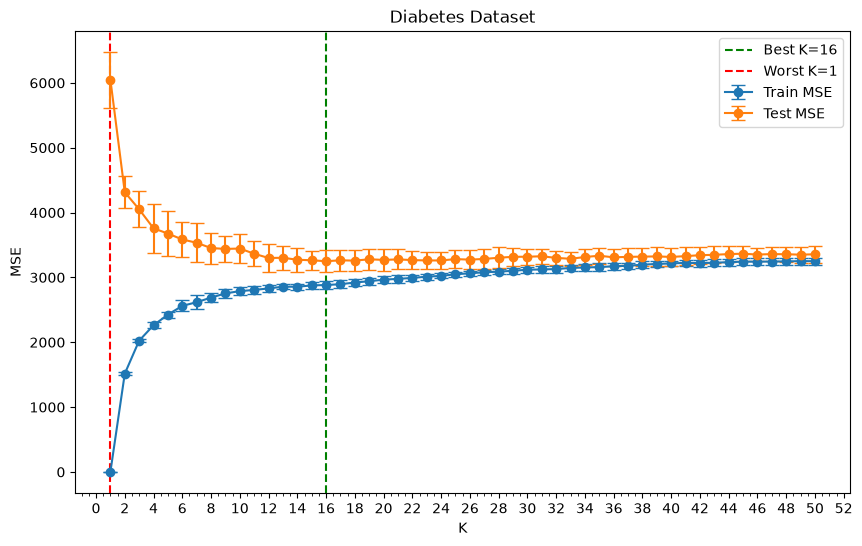

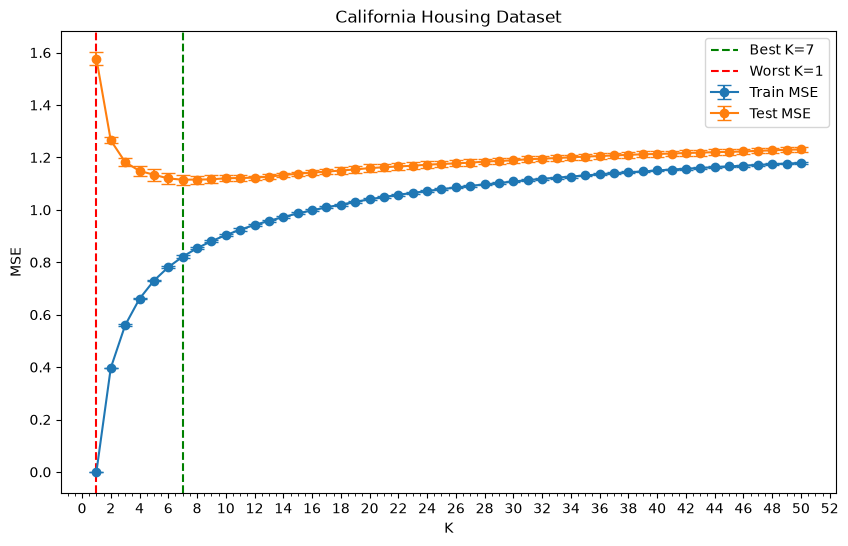

In [19]:
# REPORT: Plot results for both datasets

"""
This cell plots the results of the nested cross-validation experiments for both the diabetes and California housing datasets.
It creates two subplots, one for each dataset, showing the test MSE for each outer fold along with the mean test MSE across all folds. 
The plots provide a visual representation of the performance of the KnnRegressorCV model and allow for comparison between the two datasets.
"""


# Salient Points - display best and worst K values for both datasets
_salient_points(results_diabetes, "Diabetes")
_salient_points(results_california, "California Housing")

# Plotting the results for Diabetes dataset
plot_cv_results(results_diabetes, 'Diabetes Dataset')
plot_cv_results(results_california, 'California Housing Dataset')

### Discussion: When Does Internal CV Succeed?

For Diabetes, internal CV selected $K$ values of $[16, 15, 11, 14, 17]$ across the five outer folds (mean $K = 14.6$, modal $K = 11$). For California Housing it selected $[8, 7, 9, 9, 9]$ (mean $K = 8.4$, modal $K = 9$). Neither aggregate exactly matches the best $K$ found in Q2 ($K=16$ and $K=7$ respectively), but both land within a few neighbours of the true optimum — the mean is the more informative aggregate here, since the Diabetes selections are all distinct (making the mode arbitrary) and their mean of 14.6 sits close to the Q2 optimum of 16. This is expected — internal CV operates on ~80% of the data per outer fold, and slightly different training sets shift the CV minimum.

Despite the inexact match, the selections are functionally good because the test MSE curve is flat near the optimum for both datasets (see Q2.III plots). A difference of 2–5 in $K$ produces negligible change in test error, so the model selected by internal CV performs almost as well as the true best model.

Several factors determine how reliably internal CV identifies the best model:

* *Training set size.* With Diabetes ($N \approx 442$), each inner fold trains on only ~282 samples, producing noisy per-fold MSE estimates. California Housing is far larger and the inner CV estimate is correspondingly more stable — reflected in the low fold-to-fold variation in selected $K$ ($[8,7,9,9,9]$ vs $[16,15,11,14,17]$).
* *Flatness of the error curve.* When the optimum is sharp, even a small error in locating it leads to a noticeably worse model. When it is flat (as here), internal CV can afford to be approximate and still select a near-optimal $K$.
* *Search range boundary.* The search range is $K \in \{1, \ldots, 20\}$. For Diabetes the Q2 optimum is at $K=16$, close to the boundary, which can bias the internal CV toward lower values when training folds are slightly smaller. Extending the range to $K=50$ would remove this artefact.
* *Number of inner folds.* At $L=5$ the Diabetes CV estimate has wide error bars (Q2.III), so the selected $K$ varies considerably across outer folds. Increasing the inner fold count would reduce this variability and produce a more consistent selection.